In [2]:
from anymatrix import Anymatrix
import matlab.engine
import statistics
import matplotlib.pyplot as plt
import timeit
import numpy as np
import itertools

am = Anymatrix()
eng = matlab.engine.start_matlab()
eng.cd(r"C:\Users\propo\OneDrive - University of Leeds\Documents\MATLAB\anymatrix", nargout=1)
eng.anymatrix(nargout=0)
am.anymatrix()

Automatic anymatrix scanning done.
Help on function anymatrix in module anymatrix.main:

anymatrix(self, *varargin)
    ANYMATRIX  Interface for accessing the Anymatrix collections.
    ANYMATRIX is a user interface for the Anymatrix matrix collection.
    It provides commands to list matrices, groups and sets, search for
    matrices by properties, and obtain the matrices by their IDs.

    The interface comes with built-in groups of matrices, but users can
    develop their own groups and make them available to other users.

    The built-in collection contains 7 groups:

    contest  - the CONTEST test matrix toolbox of random matrices
                from networks.
    core     - miscellaneous matrices.
    gallery  - matrices from the MATLAB gallery.
    hadamard - a large collection of (complex) Hadamard matrices.
    matlab   - other MATLAB matrices (not in gallery).
    nessie   - matrices from real-life networks.
    regtools - matrices from regularization problems.

    Anyma

In [33]:
search_query = ["integer", "banded and square", "square and rectangular and scalable", "positive and square or hankel and real", "positive and square or hankel and real or integer"]

python_time = []

for query in search_query:
    times = timeit.repeat(f"am.anymatrix('prop', '{query}')", globals=globals(), repeat=10000, number=1)
    median_time = statistics.median(times)
    python_time.append(median_time)
    
    # Run the same query in MATLAB
    matlab_func = f"@() anymatrix('prop', '{query}')"
    matlab_times = eng.eval(f"timeit({matlab_func})", nargout=1)

print(python_time)

[7.710000136285089e-05, 0.00010869999823626131, 0.00014650000230176374, 0.00017529999968246557, 0.00021190000188653357]


In [70]:

matlab_time = []
for query in search_query:
    matlab_func = f"@() anymatrix('prop', '{query}')"
    matlab_time.append(eng.eval(f"timeit({matlab_func})", nargout=1))
    
print(matlab_time)

[0.00392469185, 0.00433809185, 0.00466019185, 0.00485579185, 0.0044648918499999996]


In [74]:
matlab_time = [0.00132338905, 0.00141728905, 0.001589489, 0.00161008905 ,0.00176758905]

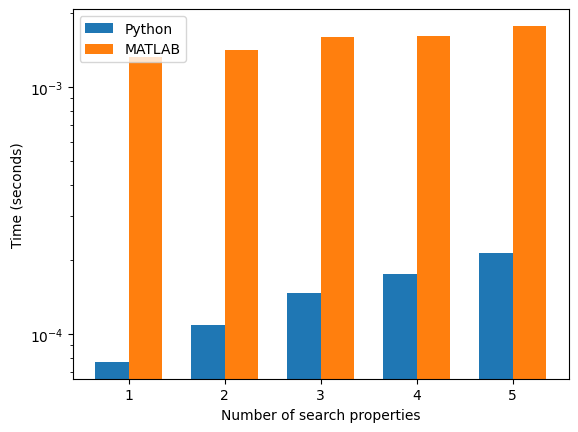

In [ ]:
import numpy as np



# Define the number of groups
n_groups = len(search_query)

# Create a figure and a set of subplots
fig, ax = plt.subplots()
ax.set_yscale('log')

# Define the index for the groups
index = np.arange(n_groups)

# Define the bar width
bar_width = 0.35

# Plot the bars
bar1 = plt.bar(index, python_time, bar_width, label='Python')
bar2 = plt.bar(index + bar_width, matlab_time, bar_width, label='MATLAB')

# Add labels, title, and legend
plt.xlabel('Number of search properties')
plt.ylabel('Time (seconds)')

# plt.title('Execution Time for Different Queries')
plt.xticks(index + bar_width / 2, [str(i+1) for i in range(n_groups)])
plt.legend(loc='upper left')
# Show the plot
plt.show()

# System scan 


In [34]:
# Run the scan command in MATLAB
command = "anymatrix('scan')"
matlab_scan_time = eng.eval(f"timeit({matlab_func}, 0)")
print(matlab_scan_time)

# Run the scan command in Python
times = timeit.repeat(f"am.anymatrix('scan')", globals=globals(), repeat=1000, number=1)
python_scan_time = statistics.median(times)


    
print(python_scan_time)

0.06516200030000001
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anymatrix scanning done.
Anyma

# Matrix Gen benchmark

In [3]:
matrix_ID = ["matlab/wilkinson", "matlab/spiral",  "matlab/magic", "matlab/invhilb", "matlab/hilb", "matlab/hadamard", "matlab/pascal", "core/beta"]
matrix_arg = [8, 128, 512, 1024]
matrix_size = []

comb = list(itertools.product(matrix_ID, matrix_arg))

matlab_runtime = []
python_runtime = []

for matrix in matrix_ID:
    print(matrix)
    python_temp = []
    matlab_temp = []
    size_temp = []
    for arg in matrix_arg:
        print(arg)
        # Get MATLAB time
        matlab_func = f"@() anymatrix('{matrix}', {arg})"
        matlab_time = eng.eval(f"timeit({matlab_func})", nargout=1)
        matlab_temp.append(matlab_time)
        
        # Get python time
        times = timeit.repeat(f"am.anymatrix('{matrix}', {arg})", globals=globals(), repeat=400, number=1)
        python_time = statistics.median(times)
        python_temp.append(python_time)
        
        # get matrix size
        matirx_size_temp = eng.eval(f"anymatrix('{matrix}', {arg})", nargout=1)
        size_temp.append(matirx_size_temp.size)
    
    matlab_runtime.append(matlab_temp)
    python_runtime.append(python_temp)
    matrix_size.append(size_temp)



matlab/wilkinson
8
128
512
1024
matlab/spiral
8
128
512
1024
matlab/magic
8
128
512
1024
matlab/invhilb
8
128
512
1024
matlab/hilb
8
128
512
1024
matlab/hadamard
8
128
512
1024
matlab/pascal
8
128
512
1024
core/beta
8
128
512


KeyboardInterrupt: 

In [4]:
matrix_ID = ["matlab/compan", "matlab/hankel", "matlab/vander", "matlab/toeplitz"]
matrix_arg = []
for i in [8, 128, 512, 1024]:
    matrix_arg.append(list(range(1, 1 + i)))

comb = list(itertools.product(matrix_ID, matrix_arg))

for matrix in matrix_ID:
    print(matrix)
    python_temp = []
    matlab_temp = []
    size_temp = []
    for arg in matrix_arg:
        print(arg)
        # Get MATLAB time
        matlab_func = f"@() anymatrix('{matrix}', {arg})"
        matlab_time = eng.eval(f"timeit({matlab_func})", nargout=1)
        matlab_temp.append(matlab_time)
        
        # Get python time
        times = timeit.repeat(f"am.anymatrix('{matrix}', {arg})", globals=globals(), repeat=400, number=1)
        python_time = statistics.median(times)
        python_temp.append(python_time)
        
        # get matrix size
        matirx_size_temp = eng.eval(f"anymatrix('{matrix}', {arg})", nargout=1)
        size_temp.append(matirx_size_temp.size)
    
    matlab_runtime.append(matlab_temp)
    python_runtime.append(python_temp)
    matrix_size.append(size_temp)



matlab/compan
[1, 2, 3, 4, 5, 6, 7, 8]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 

c:\Users\propo\OneDrive - University of Leeds\Documents\VS Code\Level3\project\anymatrix\matlab\private\vander.py:28: RuntimeWarning: overflow encountered in accumulate
  multiply.accumulate(tmp[:, 1:], out=tmp[:, 1:], axis=1)
c:\Users\propo\OneDrive - University of Leeds\Documents\VS Code\Level3\project\anymatrix\matlab\private\vander.py:28: RuntimeWarning: overflow encountered in accumulate
  multiply.accumulate(tmp[:, 1:], out=tmp[:, 1:], axis=1)
c:\Users\propo\OneDrive - University of Leeds\Documents\VS Code\Level3\project\anymatrix\matlab\private\vander.py:28: RuntimeWarning: overflow encountered in accumulate
  multiply.accumulate(tmp[:, 1:], out=tmp[:, 1:], axis=1)
c:\Users\propo\OneDrive - University of Leeds\Documents\VS Code\Level3\project\anymatrix\matlab\private\vander.py:28: RuntimeWarning: overflow encountered in accumulate
  multiply.accumulate(tmp[:, 1:], out=tmp[:, 1:], axis=1)
c:\Users\propo\OneDrive - University of Leeds\Documents\VS Code\Level3\project\anymatrix\mat

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 22

c:\Users\propo\OneDrive - University of Leeds\Documents\VS Code\Level3\project\anymatrix\matlab\private\vander.py:28: RuntimeWarning: overflow encountered in accumulate
  multiply.accumulate(tmp[:, 1:], out=tmp[:, 1:], axis=1)
c:\Users\propo\OneDrive - University of Leeds\Documents\VS Code\Level3\project\anymatrix\matlab\private\vander.py:28: RuntimeWarning: overflow encountered in accumulate
  multiply.accumulate(tmp[:, 1:], out=tmp[:, 1:], axis=1)
c:\Users\propo\OneDrive - University of Leeds\Documents\VS Code\Level3\project\anymatrix\matlab\private\vander.py:28: RuntimeWarning: overflow encountered in accumulate
  multiply.accumulate(tmp[:, 1:], out=tmp[:, 1:], axis=1)
c:\Users\propo\OneDrive - University of Leeds\Documents\VS Code\Level3\project\anymatrix\matlab\private\vander.py:28: RuntimeWarning: overflow encountered in accumulate
  multiply.accumulate(tmp[:, 1:], out=tmp[:, 1:], axis=1)
c:\Users\propo\OneDrive - University of Leeds\Documents\VS Code\Level3\project\anymatrix\mat

matlab/toeplitz
[1, 2, 3, 4, 5, 6, 7, 8]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107

C:\Users\propo\AppData\Local\Temp\ipykernel_5508\3294386547.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('RdYlGn_r')  # Reverse the colormap by adding '_r'


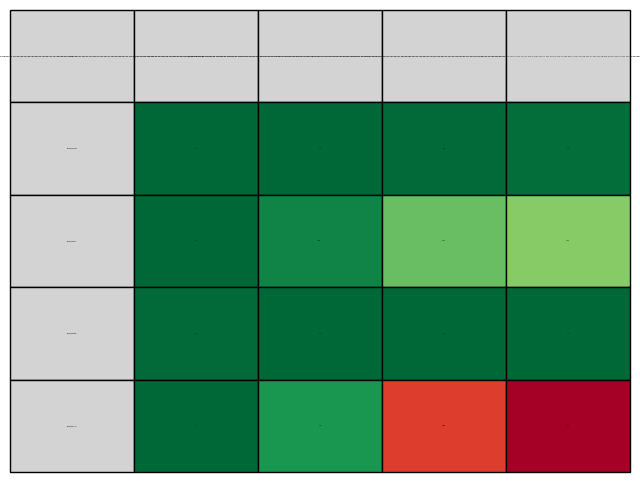

In [8]:
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from matplotlib.table import Table
# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))
ax.axis('off')

# Create table
table_data = []
values = []
for i in range(len(matrix_ID)):
    row = [matrix_ID[i]]
    for j in range(len(matrix_arg)):
        value = python_runtime[i][j] / matlab_runtime[i][j]
        row.append(f"{value:.2f}")
        values.append(value)
    table_data.append(row)

# Add header
header = ['Matrix'] + matrix_arg
table_data.insert(0, header)

# Normalize values for colormap
norm = Normalize(vmin=min(values), vmax=max(values))
cmap = get_cmap('RdYlGn_r')  # Reverse the colormap by adding '_r'

# Create table
table = Table(ax, bbox=[0, 0, 1, 1])
n_rows, n_cols = len(table_data), len(table_data[0])

# Add cells
for i in range(n_rows):
    for j in range(n_cols):
        cell_text = table_data[i][j]
        if i == 0 or j == 0:
            # Header cells
            table.add_cell(i, j, width=1/n_cols, height=1/n_rows, text=cell_text, loc='center', facecolor='lightgrey')
        else:
            # Data cells
            value = float(cell_text)
            color = cmap(norm(value))
            table.add_cell(i, j, width=1/n_cols, height=1/n_rows, text=cell_text, loc='center', facecolor=color)

# Add table to axis
ax.add_table(table)

# Display plot
plt.show()

In [ ]:
from matplotlib.table import Table
for i in range(len(matrix_ID)):
    for j in range(len(matrix_arg)):
        print(f"Matrix: {matrix_ID[i]}, Size: {matrix_size[i][j]}, Time: {python_runtime[i][j]/matlab_runtime[i][j]}")

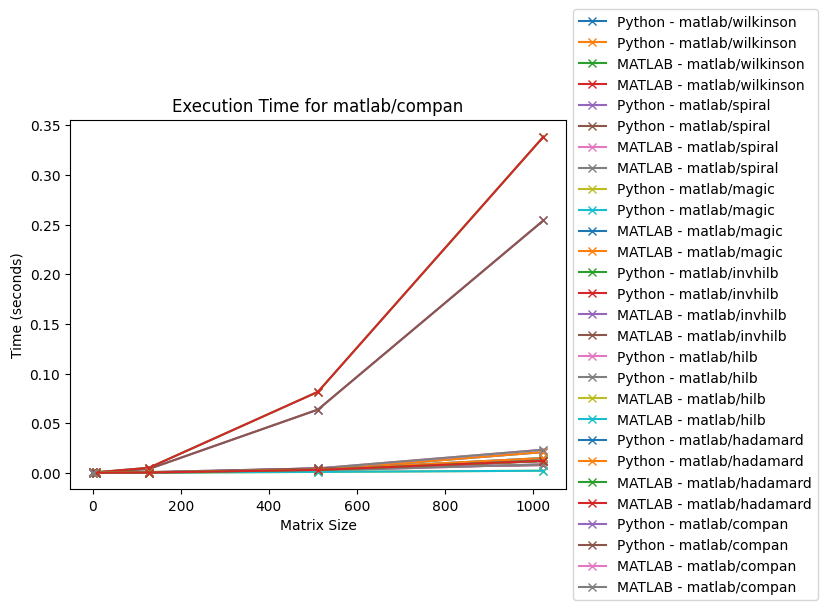

In [11]:
for i in range(len(matrix_ID)):
    plt.plot(matrix_size[i], python_runtime[i], label=f'Python - {matrix_ID[i]}', marker='x')
    plt.plot(matrix_size[i], matlab_runtime[i], label=f'MATLAB - {matrix_ID[i]}', marker='x')

plt.xlabel('Matrix Size')
plt.ylabel('Time (seconds)')
plt.title(f'Execution Time for {matrix_ID[i]}')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [14]:
matirx_size_temp = eng.eval(f"anymatrix('matlab/magic', 8)", nargout=1)
print(matirx_size_temp.size[0]* matirx_size_temp.size[1])

64


In [6]:
matrix_ID = ["matlab/wilkinson", "matlab/spiral",  "matlab/magic", "matlab/invhilb", "matlab/hilb", "matlab/hadamard", "matlab/compan", "matlab/pascal"]
matrix_size = 1024

result = []

for matrix in matrix_ID:
    matlab_func = f"@() anymatrix('{matrix}', {matrix_size})"
    matlab_time = eng.eval(f"timeit({matlab_func})", nargout=1)

    # Get python time
    times = timeit.repeat(f"am.anymatrix('{matrix}', {matrix_size})", globals=globals(), repeat=400, number=1)
    python_time = statistics.median(times)
    print(matrix, python_time/matlab_time)



matlab/wilkinson 1.9702752673753663
matlab/spiral 13.345233410211565
matlab/magic 1.1829139891908864
matlab/invhilb 39.5017870723084
matlab/hilb 3.0584706645127633
matlab/hadamard 0.847487821741565
matlab/compan 1.3186714282560899


KeyboardInterrupt: 

In [9]:
matrix_ID = ["core/beta"]
matrix_size = 100

result = []

for matrix in matrix_ID:
    matlab_func = f"@() anymatrix('{matrix}', {matrix_size})"
    matlab_time = eng.eval(f"timeit({matlab_func})", nargout=1)

    # Get python time
    times = timeit.repeat(f"am.anymatrix('{matrix}', {matrix_size})", globals=globals(), repeat=400, number=1)
    python_time = statistics.median(times)
    print(matrix, python_time/matlab_time)



core/beta 42.93681162797836


In [11]:
matrix_ID = ["matlab/spiral"]
matrix_size = 1000

result = []

for matrix in matrix_ID:
    matlab_func = f"@() anymatrix('{matrix}', {matrix_size})"
    matlab_time = eng.eval(f"timeit({matlab_func})", nargout=1)

    # Get python time
    times = timeit.repeat(f"am.anymatrix('{matrix}', {matrix_size})", globals=globals(), repeat=400, number=1)
    python_time = statistics.median(times)
    print(matrix, python_time/matlab_time)



matlab/spiral 18.068615133241103
